In [1]:
# Importing necessary libraries for data processing, model building, and evaluation
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
# Load the dataset from the Excel file
df = pd.read_excel("final_panel_data.xlsx")

In [3]:
# Selecting the features for the model
features = ['Return on Asset', 'Asset turnover', 'Real Interest Rate', 'GDP growth Annual', 'Electricity Prices']
X = df[features]  # Independent variables
y = df['y']  # Dependent variable (target)

In [4]:
# Scaling the features using MinMaxScaler to bring all features into the same range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # Scaled features


In [5]:
# Splitting the dataset into training, validation, and test sets
# 70% training data, 30% temporary data; temporary data further split into 2/3 test and 1/3 validation
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=0)

In [6]:
# Defining the hyperparameter grid for tuning the SVM model
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 0.01, 0.1, 1],  # Kernel coefficient
    'kernel': ['rbf', 'poly']  # Type of kernel (Radial Basis Function or Polynomial)
}

In [7]:
# Performing grid search to find the best model with cross-validation (5-fold)
grid = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)  # Fit the grid search on training data

GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             scoring='accuracy')

In [8]:
# Extracting the best model from the grid search
best_model = grid.best_estimator_

In [9]:
# Predicting the target variable for the train, validation, and test datasets using the best model
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

In [10]:
# Calculating accuracy for training, validation, and test datasets
train_acc = accuracy_score(y_train, y_train_pred)  # Training accuracy
val_acc = accuracy_score(y_val, y_val_pred)  # Validation accuracy
test_acc = accuracy_score(y_test, y_test_pred)  # Test accuracy


In [11]:
# Printing the best parameters obtained from GridSearchCV
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [12]:
# Evaluating the model's performance on the test set
print("\n--- Test Set Evaluation ---")
print("Accuracy:", test_acc)  # Test accuracy
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))  # Confusion matrix
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))  # Classification report
print("AUC-ROC Score:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]))  # AUC-ROC score


--- Test Set Evaluation ---
Accuracy: 0.8575367647058824

Confusion Matrix:
 [[773  35]
 [120 160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       808
           1       0.82      0.57      0.67       280

    accuracy                           0.86      1088
   macro avg       0.84      0.76      0.79      1088
weighted avg       0.85      0.86      0.85      1088

AUC-ROC Score: 0.8799482850070721


In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# X =  features
# y =  target

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

fold = 1
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train SVM model
    model = SVC(kernel='rbf', probability=True, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f"Fold {fold} - Validation Accuracy: {acc:.4f}")
    fold += 1

# Average accuracy and standard deviation
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\nAverage CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

Fold 1 - Validation Accuracy: 0.8482
Fold 2 - Validation Accuracy: 0.8565
Fold 3 - Validation Accuracy: 0.8684
Fold 4 - Validation Accuracy: 0.8592
Fold 5 - Validation Accuracy: 0.8545

Average CV Accuracy: 0.8574 ± 0.0066


In [26]:
# Creating a table to compare the accuracies from different datasets and cross-validation
results = pd.DataFrame({
    'Dataset': ['Training (In-sample)', 'Validation (Out-of-sample)', 'Test (Out-of-sample)', 'Cross-Validation (5-fold)'],
    'Accuracy': [train_acc, val_acc, test_acc, np.mean(accuracies)]  # Now works
})

# Displaying the results
print("\n=== In-Sample vs Out-of-Sample Accuracy ===")
print(results)


=== In-Sample vs Out-of-Sample Accuracy ===
                      Dataset  Accuracy
0        Training (In-sample)  0.860899
1  Validation (Out-of-sample)  0.856354
2        Test (Out-of-sample)  0.857537
3   Cross-Validation (5-fold)  0.857379


C:\Users\FC\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


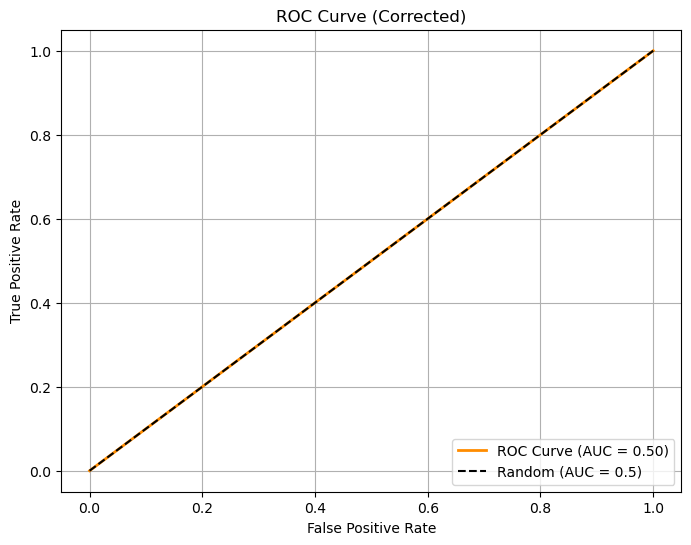

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probabilities for class 1 (MUST USE predict_proba)
y_probs = best_model.predict_proba(X_test)[:, 1]  # ← Use [:, 1] for class 1

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Corrected)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()